# NVDA Heston Pipeline — End-to-End (mirrors the app)

This notebook runs the **same pipeline the Streamlit app runs**, by calling the very
same service functions the app pages use — not a re-implementation. So whatever you
see here is what the app produces:

1. SOFR/OIS curve → 2. fetch live chain → 3. liquidity filter →
4. **calibrate** (`calibrate_option_chain`) — de-Americanizes the quotes internally,
   then fits the Heston CF with Levenberg-Marquardt (Cui et al. 2016) →
5. **price + analytics** (`build_chain_analytics`) — prices the **European Heston**
   model, **de-Americanizes the market** for `market_iv`, and computes IVs / Greeks /
   mispricing →
6. vol surface (de-Am market IV vs European model IV) → 7. mispricing.

Everything is **European-equivalent and consistent**: the market side is
de-Americanized, the model side is European Heston, and they are compared like-for-like.
No PDE / LSMC anywhere.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata
from datetime import datetime

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid', palette='muted')

print(f'Notebook run: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

Notebook run: 2026-07-02 02:29:30


## Step 1 — SOFR / OIS rate curve

In [2]:
from config.market_config import get_ois_curve, interpolate_rate, curve_summary, maturity_label

rate_curve = get_ois_curve(force_refresh=True)
R = interpolate_rate(rate_curve, 0.25)
print('SOFR / OIS curve:')
for T, r in sorted(rate_curve.items()):
    print(f'  {maturity_label(T):<6} {T:<8.4f} {r*100:>6.3f}%')
print(f'3M SOFR (R): {R*100:.3f}%')

SOFR / OIS curve:
  O/N    0.0027    3.680%
  30D    0.0822    3.633%
  3M     0.2466    3.635%
  6M     0.4932    3.671%
  5Y     5.0000    4.232%
  10Y    10.0000   4.475%
3M SOFR (R): 3.636%


## Step 2 — Fetch live NVDA chain  (Fetch Data page)

In [3]:
TICKER = '^SPX'
from data.market_data import get_all_options

raw_df = get_all_options(TICKER)
SPOT = raw_df['spot'].iloc[0]
div = (raw_df.groupby('ticker')['dividend_yield'].first()
       if 'dividend_yield' in raw_df.columns else {})
Q = float(div.get(TICKER, 0.0))
print(f'{TICKER}: spot ${SPOT:.2f} | div {Q*100:.3f}% | {len(raw_df):,} raw contracts | '
      f'{raw_df["maturity"].nunique()} maturities')

^SPX: spot $7483.23 | div -6.775% | 17,568 raw contracts | 51 maturities


## Step 3 — Liquidity filter  (Filter Options page)

In [4]:
from services.market_service import filter_chain_with_stats

filtered_df, filter_stats = filter_chain_with_stats(
    raw_df,
    spread_limit=0.05,
    rate_curve=rate_curve,
    min_volume=0,
    min_open_interest=0,
    moneyness_lo=0.8,
    moneyness_hi=1.2,
)
print(f'{len(raw_df):,} -> {len(filtered_df):,} contracts '
      f'({filtered_df["maturity"].nunique()} expiries, '
      f'q={filtered_df["q"].iloc[0]*100:.3f}%)')
for reason, n in filter_stats.items():
    print(f'  {reason:<34} {n:>6,}')

17,568 -> 9,308 contracts (47 expiries, q=-4.258%)
  Rel. spread ≥ 5%                    4,798
  Moneyness outside [0.8, 1.2]        2,631
  Arbitrage violation                   362
  Maturity < 7d                         469


## Step 4 — Calibrate  (Calibrate Heston page)

`calibrate_option_chain` is the exact function the app calls. It de-Americanizes the
calibration quotes internally, then fits the five parameters via the analytic-gradient
LM. Bounds/guess default to `DEFAULT_BOUNDS` / `DEFAULT_INITIAL_GUESS` — the same values
the app's editable table is seeded with (edit `BOUNDS` below to mirror changing the table).

In [5]:
from services.pricing_service import HestonParameters
DEFAULT_BOUNDS: list[tuple[float, float]] = [
    (0.001, 0.95),     # v0
    (0.50, 10.00),     # kappa
    (0.001, 0.95),     # theta (long-run variance, v_bar)
    (0.05, 5.00),     # sigma (vol-of-vol)
    (-0.90, -0.10),   # rho
]
DEFAULT_INITIAL_GUESS = HestonParameters(v0=0.20, kappa=1.20, theta=0.20, sigma=0.30, rho=-0.60)

In [6]:
from services.calibration_service import calibrate_option_chain

BOUNDS = list(DEFAULT_BOUNDS)        # edit to taste (mirrors the app's bounds table)
GUESS  = DEFAULT_INITIAL_GUESS

res_cal, cal_df = calibrate_option_chain(
    filtered_df, rate_curve=rate_curve, initial_guess=GUESS, bounds=BOUNDS,
)
p = res_cal.params
feller = 2 * p.kappa * p.theta - p.sigma ** 2

print(f'Done in {res_cal.runtime_seconds:.2f}s | contracts used {res_cal.contract_count} | '
      f'IV-RMSE {res_cal.iv_rmse*100:.2f} vpts | IV-MAE {res_cal.iv_mae*100:.2f} vpts')
print()
names = ['v0', 'kappa', 'theta', 'sigma', 'rho']
for n, v, (lo, hi) in zip(names, p.as_tuple(), BOUNDS):
    atb = abs(v - lo) < 1e-3 * max(1, abs(lo)) or abs(v - hi) < 1e-3 * max(1, abs(hi))
    print(f'  {n:6} = {v:+.4f}   in [{lo:+.3f}, {hi:+.3f}]{"   <-- AT BOUND" if atb else ""}')
print(f'  Feller 2kt-s^2 = {feller:+.4f}  ({"satisfied" if feller > 0 else "violated"})')
print(f'  init vol {p.v0**0.5*100:.1f}%   long-run vol {p.theta**0.5*100:.1f}%')

Done in 47.42s | contracts used 5482 | IV-RMSE 0.64 vpts | IV-MAE 0.43 vpts

  v0     = +0.0169   in [+0.001, +0.950]
  kappa  = +5.0582   in [+0.500, +10.000]
  theta  = +0.0510   in [+0.001, +0.950]
  sigma  = +1.4686   in [+0.050, +5.000]
  rho    = -0.6387   in [-0.900, -0.100]
  Feller 2kt-s^2 = -1.6406  (violated)
  init vol 13.0%   long-run vol 22.6%


## Step 5 — Price + analytics  (Price Contracts page)

`build_chain_analytics` is exactly what the Price Contracts page now calls. It:
- prices every contract with the **European Heston** closed form (`model_price`),
- **de-Americanizes the market** quotes → `euro_mid`, `deam_iv`, and sets
  `market_iv = deam_iv`,
- inverts the model price to `model_iv`, and computes Greeks + mispricing.

So `market_iv` is the de-Americanized (European-equivalent) IV and `model_iv` is the
European model IV — directly comparable.

In [7]:
from services.analytics_service import build_chain_analytics

df = build_chain_analytics(
    filtered_df,
    r=R, q=Q,
    rate_curve=rate_curve,
    heston_params=res_cal.params,
    compute_model_prices=True,
    pricing_limit=None,            # price the whole chain
)

print(f'Priced {df["model_price"].notna().sum():,} / {len(df):,} contracts (European Heston)')
show = [c for c in ['type','maturity','strike','T','mid_price','euro_mid',
                    'model_price','market_iv','model_iv','iv_error','mispricing_bias']
        if c in df.columns]
print(len(df))
df.head()

Priced 9,308 / 9,308 contracts (European Heston)
9308


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,...,model_delta,model_gamma,model_vega,model_theta,model_rho,model_abs_delta,price_error,iv_error,relative_price_error,abs_iv_error,mispricing_score,mispricing_bias
0,SPXW260710C06000000,2026-06-25 17:54:44+00:00,6000.0000,1369.2100,1485.2000,1509.0000,0.0000,0.0000,1.0000,0,0.8060,True,...,0.9972,0.0000,12.1574,-696.1129,129.0826,0.9972,-1.5174,-0.0797,-0.0010,0.0797,0.1076,sell
1,SPXW260710C06100000,2026-06-30 15:51:03+00:00,6100.0000,1390.7900,1385.4000,1408.1000,0.0000,0.0000,1.0000,0,0.7519,True,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.4037,NaN,-0.0017,NaN,NaN,hold
2,SPXW260710C06150000,2026-07-01 13:45:58+00:00,6150.0000,1318.8300,1335.4000,1358.6000,0.0000,0.0000,2.0000,0,0.7295,True,...,0.9954,0.0000,17.4773,-756.5756,132.0174,0.9954,-0.9602,-0.0432,-0.0007,0.0432,0.0585,sell
3,SPXW260710C06200000,2026-06-29 16:04:43+00:00,6200.0000,1226.5000,1285.4000,1308.8000,0.0000,0.0000,2.0000,0,0.7056,True,...,0.9980,0.0000,9.7506,-649.2943,133.5421,0.9980,-1.6334,-0.0889,-0.0013,0.0889,0.1203,sell
4,SPXW260710C06250000,2026-06-25 17:54:44+00:00,6250.0000,1120.6100,1235.6000,1258.0000,0.0000,0.0000,1.0000,0,0.6778,True,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.8797,NaN,-0.0023,NaN,NaN,hold


In [8]:
df[df['model_price'] < 0]['model_price']

Series([], Name: model_price, dtype: float64)

In [9]:
# Accuracy — straight from the analytics columns (model European vs de-Am market)
df['abs_error'] = df['price_error'].abs()
print('Overall (model European vs de-Americanized market):')
print(f'  MAE                : ${df["abs_error"].mean():.4f}')
print(f'  Mean |IV error|    : {df["iv_error"].abs().mean()*100:.2f} vol pts')
print(f'  Mean (de-Am) market IV {df["market_iv"].mean()*100:.1f}%  vs model IV {df["model_iv"].mean()*100:.1f}%')
print()
df['T_bucket'] = pd.cut(df['T'], bins=[0, 0.1, 0.5, 1.0, 3.0], labels=['< 1M','1-6M','6M-1Y','1-3Y'])
acc = df.groupby('T_bucket', observed=True).agg(
    N=('model_price','count'),
    MAE=('abs_error','mean'),
    iv_err=('iv_error', lambda x: x.abs().mean()),
)
acc['MAE'] = acc['MAE'].map('${:.4f}'.format)
acc['iv_err'] = (acc['iv_err']*100).map('{:.2f} vpts'.format)
print('By maturity bucket:')
print(acc.to_string())

Overall (model European vs de-Americanized market):
  MAE                : $8.9517
  Mean |IV error|    : 0.73 vol pts
  Mean (de-Am) market IV 17.8%  vs model IV 17.7%

By maturity bucket:
             N       MAE     iv_err
T_bucket                           
< 1M      2209   $3.7669  0.93 vpts
1-6M      4744   $6.1576  0.65 vpts
6M-1Y     1750  $12.3422  0.60 vpts
1-3Y       566  $31.9749  0.89 vpts


### What de-Americanization did (inside the pipeline)

`build_chain_analytics` already de-Americanized the market side; here we just read the
`euro_mid` (European-equivalent) vs raw `mid_price` to see the early-exercise premium
that was stripped before any comparison.

In [10]:
df['ex_premium'] = df['mid_price'] - df['euro_mid']
for typ in ('call', 'put'):
    s = df[(df.type == typ) & df['deam_iv'].notna()]
    if not s.empty:
        print(f'  {typ:<5}: mean premium ${s["ex_premium"].mean():.4f}  '
              f'max ${s["ex_premium"].max():.4f}  '
              f'({(s["ex_premium"]/s["mid_price"]).mean()*100:.2f}% of mid)')

  call : mean premium $0.0000  max $0.0000  (0.00% of mid)
  put  : mean premium $0.0000  max $0.0000  (0.00% of mid)


## Step 6 — Volatility surface  (Volatility Surface page)

Market surface = **de-Americanized** market IV; model surface = **European Heston**
model IV. Like-for-like.

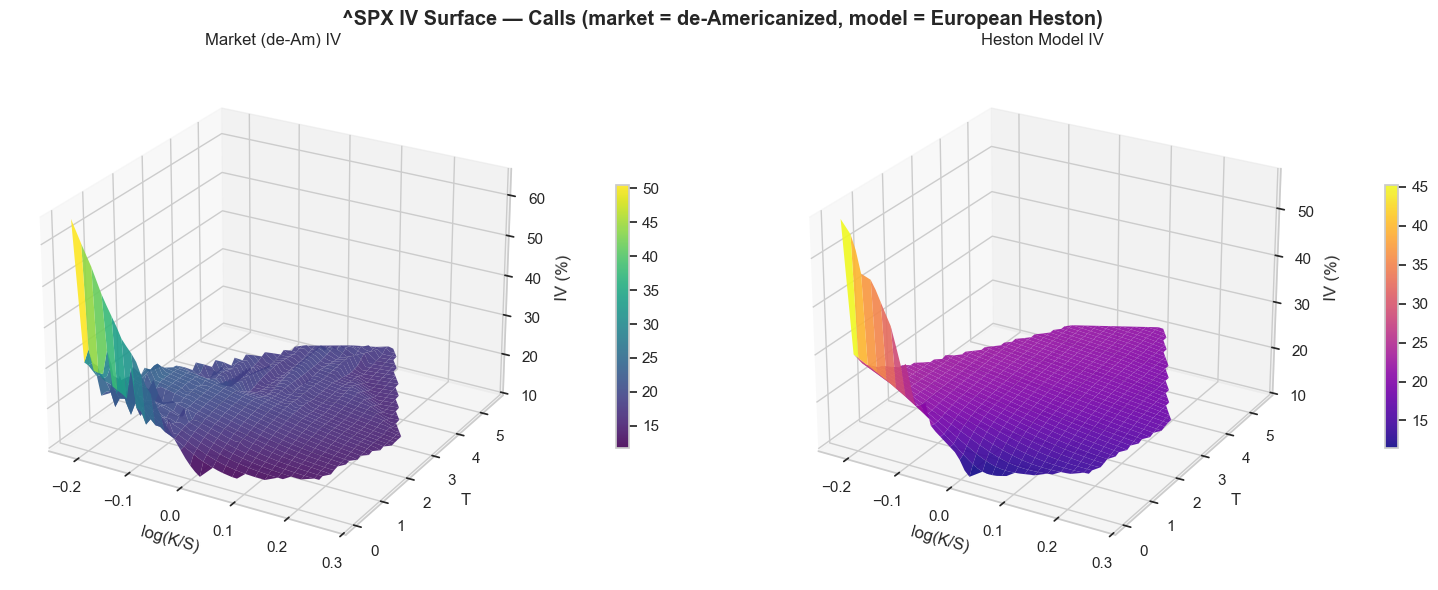

In [11]:
surf = df[(df['type'] == 'call') & df['market_iv'].notna() & df['model_iv'].notna()
          & (df['market_iv'] > 0.05)].copy()
surf['log_m'] = np.log(surf['moneyness'])
lm = np.linspace(surf['log_m'].min(), surf['log_m'].max(), 55)
Tg = np.linspace(surf['T'].min(), surf['T'].max(), 45)
LM, TT = np.meshgrid(lm, Tg)
Z_mkt = griddata((surf['log_m'], surf['T']), surf['market_iv']*100, (LM, TT), method='linear')
Z_mdl = griddata((surf['log_m'], surf['T']), surf['model_iv']*100,  (LM, TT), method='linear')

fig = plt.figure(figsize=(16, 6))
fig.suptitle(f'{TICKER} IV Surface — Calls (market = de-Americanized, model = European Heston)',
             fontweight='bold')
for i, (Z, t, cm) in enumerate([(Z_mkt,'Market (de-Am) IV','viridis'),
                                (Z_mdl,'Heston Model IV','plasma')], 1):
    ax = fig.add_subplot(1, 2, i, projection='3d')
    sp = ax.plot_surface(LM, TT, Z, cmap=cm, alpha=0.9, linewidth=0)
    ax.set_xlabel('log(K/S)'); ax.set_ylabel('T'); ax.set_zlabel('IV (%)')
    ax.set_title(t); ax.view_init(elev=25, azim=-60)
    plt.colorbar(sp, ax=ax, shrink=0.5, pad=0.1)
plt.tight_layout(); plt.show()

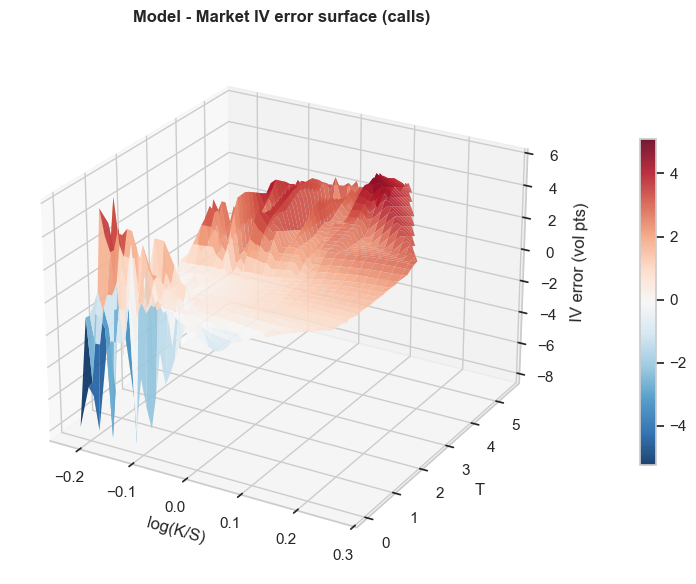

In [12]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
sp = ax.plot_surface(LM, TT, Z_mdl - Z_mkt, cmap='RdBu_r', alpha=0.9, linewidth=0)
ax.set_xlabel('log(K/S)'); ax.set_ylabel('T'); ax.set_zlabel('IV error (vol pts)')
ax.set_title('Model - Market IV error surface (calls)', fontweight='bold')
ax.view_init(elev=25, azim=-60); plt.colorbar(sp, ax=ax, shrink=0.6, pad=0.1)
plt.tight_layout(); plt.show()

## Step 7 — Mispricing  (Mispricing Screener page)

Ranked by the analytics `mispricing_score` / `iv_error` (model vs de-Americanized
market, European-equivalent). `mispricing_bias`: buy = market cheap vs model, sell = rich.

In [13]:
SHOW = ['type','maturity','strike','T','euro_mid','model_price',
        'market_iv','model_iv','iv_error','mispricing_bias']
liq = df[df['mispricing_score'].notna()].copy()
print('Top 8 — market CHEAP vs model (iv_error > 0 -> buy):')
print(liq.nlargest(8, 'iv_error')[SHOW].to_string(index=False))
print()
print('Top 8 — market RICH vs model (iv_error < 0 -> sell):')
print(liq.nsmallest(8, 'iv_error')[SHOW].to_string(index=False))

Top 8 — market CHEAP vs model (iv_error > 0 -> buy):
type   maturity    strike      T  euro_mid  model_price  market_iv  model_iv  iv_error mispricing_bias
call 2026-09-18 6425.0000 0.2134 1110.1000    1139.1571     0.1125    0.2485    0.1360             buy
call 2026-12-31 7105.0000 0.4983  514.4000     695.5517     0.0617    0.1921    0.1304             buy
call 2026-09-18 6620.0000 0.2134  917.1000     956.3824     0.1104    0.2309    0.1205             buy
call 2026-09-30 6530.0000 0.2463 1009.0000    1050.6988     0.1185    0.2364    0.1178             buy
call 2026-08-31 6770.0000 0.1641  757.0500     791.9991     0.1102    0.2200    0.1098             buy
call 2026-10-16 6430.0000 0.2901 1125.6000    1169.4802     0.1343    0.2425    0.1082             buy
call 2026-09-18 6630.0000 0.2134  908.3000     947.1036     0.1243    0.2300    0.1057             buy
call 2026-07-17 6605.0000 0.0408  896.4000     897.8759     0.1827    0.2759    0.0932             buy

Top 8 — market RICH

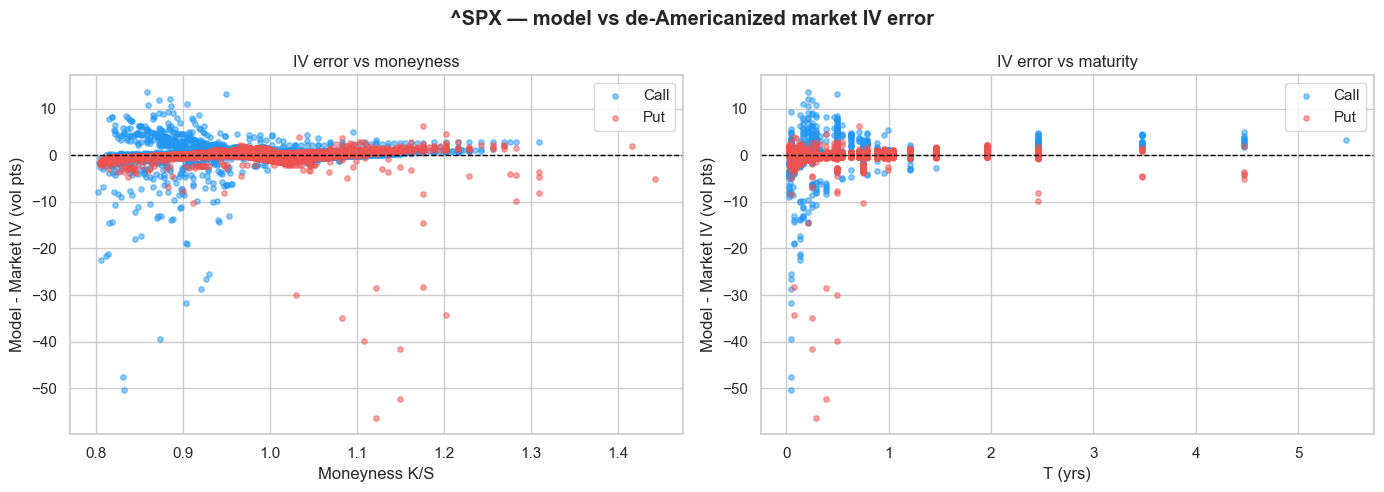

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{TICKER} — model vs de-Americanized market IV error', fontweight='bold')
for ax, x, xl in [(axes[0],'moneyness','Moneyness K/S'), (axes[1],'T','T (yrs)')]:
    for typ, c in [('call','#2196F3'), ('put','#EF5350')]:
        s = df[df.type == typ]
        ax.scatter(s[x], s['iv_error']*100, s=15, alpha=0.5, color=c, label=typ.capitalize())
    ax.axhline(0, color='black', lw=1, ls='--'); ax.set_xlabel(xl)
    ax.set_ylabel('Model - Market IV (vol pts)'); ax.legend()
axes[0].set_title('IV error vs moneyness'); axes[1].set_title('IV error vs maturity')
plt.tight_layout(); plt.show()

## Summary

In [15]:
print('=' * 60)
print(f'  {TICKER} HESTON PIPELINE (as in the app)')
print('=' * 60)
print(f'  Spot ${SPOT:.2f} | div {Q*100:.3f}% | rate {curve_summary(rate_curve)}')
print(f'  Contracts: {len(raw_df):,} raw -> {len(filtered_df):,} filtered')
print()
print(f'  Calibration (de-Americanized CF, LM)')
print(f'    v0={p.v0:.4f}  kappa={p.kappa:.4f}  theta={p.theta:.4f}  '
      f'sigma={p.sigma:.4f}  rho={p.rho:+.4f}')
print(f'    Feller {feller:+.4f}  | IV-RMSE {res_cal.iv_rmse*100:.2f} vpts | IV-MAE {res_cal.iv_mae*100:.2f} vpts | {res_cal.runtime_seconds:.1f}s')
print()
print(f'  Pricing/analytics (European Heston model vs de-Am market)')
print(f'    MAE ${df["abs_error"].mean():.4f} | mean |IV err| {df["iv_error"].abs().mean()*100:.2f} vpts')
print('=' * 60)

  ^SPX HESTON PIPELINE (as in the app)
  Spot $7483.23 | div -6.775% | rate 3M: 3.63%  |  6M: 3.67%  |  5Y: 4.23%  |  10Y: 4.47%
  Contracts: 17,568 raw -> 9,308 filtered

  Calibration (de-Americanized CF, LM)
    v0=0.0169  kappa=5.0582  theta=0.0510  sigma=1.4686  rho=-0.6387
    Feller -1.6406  | IV-RMSE 0.64 vpts | IV-MAE 0.43 vpts | 47.4s

  Pricing/analytics (European Heston model vs de-Am market)
    MAE $8.9517 | mean |IV err| 0.73 vpts
